# Student Dropout Prediction

This notebook explores the use of machine learning techniques to predict whether a university student will drop out or successfully graduate based on demographic and academic indicators.

The analysis follows a structured data science workflow consisting of:

1. Data Understanding
2. Exploratory Data Analysis
3. Data Preparation
4. Model Training
5. Model Evaluation

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
sns.set(style="whitegrid")

## 2. Load Dataset

The dataset used in this project contains demographic, academic, and socio-economic indicators describing university students. The goal is to predict whether a student will drop out or successfully graduate.

In [2]:
df = pd.read_csv("../datasets/data.csv", sep=";")

df.head()

,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


## 3. Dataset Overview

Before building machine learning models, it is important to understand the structure of the dataset.

### Shape

In [3]:
df.shape

(4424, 37)

### Column Names

In [4]:
df.columns

Index(['Marital status', 'Application mode', 'Application order', 'Course',
       'Daytime/evening attendance\t', 'Previous qualification',
       'Previous qualification (grade)', 'Nacionality',
       'Mother's qualification', 'Father's qualification',
       'Mother's occupation', 'Father's occupation', 'Admission grade',
       'Displaced', 'Educational special needs', 'Debtor',
       'Tuition fees up to date', 'Gender', 'Scholarship holder',
       'Age at enrollment', 'International',
       'Curricular units 1st sem (credited)',
       'Curricular units 1st sem (enrolled)',
       'Curricular units 1st sem (evaluations)',
       'Curricular units 1st sem (approved)',
       'Curricular units 1st sem (grade)',
       'Curricular units 1st sem (without evaluations)',
       'Curricular units 2nd sem (credited)',
       'Curricular units 2nd sem (enrolled)',
       'Curricular units 2nd sem (evaluations)',
       'Curricular units 2nd sem (approved)',
       'Curricular units 2nd

### Data Types

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Marital status                                  4424 non-null   int64  
 1   Application mode                                4424 non-null   int64  
 2   Application order                               4424 non-null   int64  
 3   Course                                          4424 non-null   int64  
 4   Daytime/evening attendance	                     4424 non-null   int64  
 5   Previous qualification                          4424 non-null   int64  
 6   Previous qualification (grade)                  4424 non-null   float64
 7   Nacionality                                     4424 non-null   int64  
 8   Mother's qualification                          4424 non-null   int64  
 9   Father's qualification                          4424

## 4. Target Variable Distribution

The dataset contains three possible outcomes:

- Dropout
- Enrolled
- Graduate

Since the final outcome of "Enrolled" students is unknown, these observations will later be removed from the dataset.

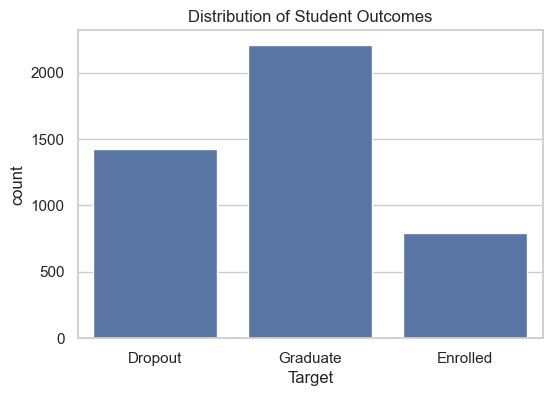

In [6]:
df["Target"].value_counts()

plt.figure(figsize=(6,4))
sns.countplot(x="Target", data=df)
plt.title("Distribution of Student Outcomes")
plt.show()

## 5. Filtering the Dataset

The "Enrolled" category represents students whose final academic outcome is not yet determined. To avoid label uncertainty, these observations are removed from the dataset.

The prediction task therefore becomes a binary classification problem:

1 = Dropout  
0 = Graduate

In [7]:
# Remove whitespace
df["Target"] = df["Target"].str.strip()

df = df[df["Target"] != "Enrolled"]

In [8]:
df["Target"].value_counts()

Target
Graduate    2209
Dropout     1421
Name: count, dtype: int64

### Convert Target to Binary

In [ ]:
df["Target"] = df["Target"].map({
    "Dropout": 1,
    "Graduate": 0
})

df["Target"].value_counts()

Target
0    2209
1    1421
Name: count, dtype: int64

In [10]:
print(df["Target"].unique())

[1 0]
